EDA EXPLORATORIO - DATATHON PASSOS MÁGICOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

1. CONFIGURAÇÃO DE AMBIENTE E DIRETÓRIOS

In [2]:
# Ajustar o diretório de trabalho caso o notebook esteja na pasta /notebooks
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
print(f"Diretório de trabalho atual: {os.getcwd()}")

# Garantir que a pasta de destino para os dados processados exista
os.makedirs('../data/processed', exist_ok=True)

Diretório de trabalho atual: d:\cursos\fiap\machine learning\5mlet_tc_05\5mlet_tc_05\notebook


2. FUNÇÃO ROBUSTA DE CARREGAMENTO (EVITA DUPLICATAS E KEYERRORS)

In [3]:
def load_and_standardize(xls, sheet_name, year):
    """
    Carrega uma aba do Excel e garante que os nomes das colunas sejam únicos e padronizados.
    """
    df = pd.read_excel(xls, sheet_name=sheet_name)
    
    # 1. Padronização básica: remover espaços e colocar em maiúsculas
    df.columns = [str(col).strip().upper() for col in df.columns]
    
    # 2. Renomeação Inteligente (Garante nomes amigáveis e únicos)
    new_cols = []
    found_keys = set()
    
    for col in df.columns:
        # Mapeamento para Pedra [cite: 61, 73, 98]
        if 'PEDRA' in col and 'Pedra' not in found_keys:
            new_cols.append('Pedra')
            found_keys.add('Pedra')
        # Mapeamento para Defasagem [cite: 90]
        elif 'DEFA' in col and 'Defasagem' not in found_keys:
            new_cols.append('Defasagem')
            found_keys.add('Defasagem')
        # Mapeamento para INDE [cite: 59, 76, 94]
        elif 'INDE' in col and 'INDE' not in found_keys:
            new_cols.append('INDE')
            found_keys.add('INDE')
        # Outros indicadores (IDA, IEG, etc.) [cite: 66, 68, 121]
        elif any(ind in col for ind in ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN']):
            clean_name = next(ind for ind in ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN'] if ind in col)
            if clean_name not in found_keys:
                new_cols.append(clean_name)
                found_keys.add(clean_name)
            else:
                new_cols.append(col)
        else:
            new_cols.append(col)
            
    df.columns = new_cols
    
    # 3. Remover colunas duplicadas (Garante que o Index seja único)
    df = df.loc[:, ~df.columns.duplicated()]
    
    df['Ano_Referencia'] = year
    return df

3. EXECUÇÃO DO CARREGAMENTO E CONCATENAÇÃO

In [4]:
print("\n" + "=" * 80)
print("PROCESSANDO DADOS (2022-2024)")
print("=" * 80)

file_path = '../data/raw/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

try:
    xls = pd.ExcelFile(file_path)
    df_2022 = load_and_standardize(xls, 'PEDE2022', 2022)
    df_2023 = load_and_standardize(xls, 'PEDE2023', 2023)
    df_2024 = load_and_standardize(xls, 'PEDE2024', 2024)

    # Concatenação agora segura sem InvalidIndexError
    df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)
    
    # Limpeza de strings problemáticas
    df = df.replace(['#N/A', 'ERROR', 'INCLUIR', 'NAN', 'null', 'nan'], np.nan)
    
    print(f"Dataset consolidado com {df.shape[0]} registros.")
except Exception as e:
    print(f"Ocorreu um erro no carregamento: {e}")
    raise


PROCESSANDO DADOS (2022-2024)
Dataset consolidado com 3030 registros.


4. FEATURE ENGINEERING - CLASSIFICAÇÃO ORDINAL

In [5]:
# Mapeamento das Pedras conforme o nível de aprendizado do INDE [cite: 61, 126]
# Quartzo (2.4-5.5) < Ágata (5.5-6.8) < Ametista (6.8-8.2) < Topázio (8.2-9.2)
pedra_mapping = {
    'QUARTZO': 1,
    'ÁGATA': 2,
    'AMETISTA': 3,
    'TOPÁZIO': 4
}

if 'Pedra' in df.columns:
    # A CORREÇÃO ESTÁ AQUI: Adicionado .str antes de .upper()
    df['Pedra'] = df['Pedra'].astype(str).str.strip().str.upper() 
    df['Pedra_Nivel'] = df['Pedra'].map(pedra_mapping)
    print("Sucesso: Coluna 'Pedra_Nivel' criada com base na classificação oficial.")

Sucesso: Coluna 'Pedra_Nivel' criada com base na classificação oficial.


5. ANÁLISE DA TARGET E PREVENÇÃO DE LEAKAGE


ANÁLISE DE CORRELAÇÃO (PREVENÇÃO DE DATA LEAKAGE)


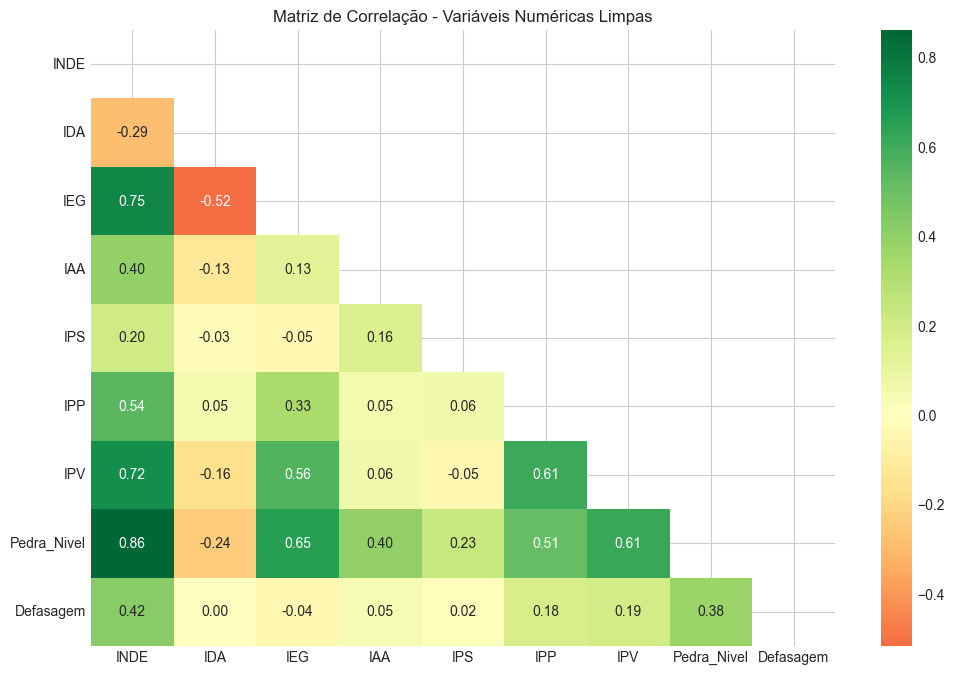

In [6]:
# 1. Lista de colunas que desejamos analisar
features_analise = ['INDE', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Pedra_Nivel', 'Defasagem']

# 2. Filtrar apenas as colunas que realmente existem no DataFrame [cite: 55, 121]
cols_existentes = [c for c in features_analise if c in df.columns]

# 3. CONVERSÃO CRÍTICA: Garantir que todas sejam numéricas
# Isso remove o erro de 'datetime' transformando valores inválidos em NaN [cite: 34]
for col in cols_existentes:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Filtrar colunas que permaneceram numéricas (segurança adicional)
df_corr = df[cols_existentes].select_dtypes(include=[np.number])

# 5. Calcular a correlação apenas com dados numéricos
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÃO (PREVENÇÃO DE DATA LEAKAGE)")
print("=" * 80)

plt.figure(figsize=(12, 8))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Matriz de Correlação - Variáveis Numéricas Limpas')
plt.show()

6. RESUMO PARA MODELAGEM - SALVAMENTO FINAL

In [7]:
print("\n" + "=" * 80)
print("CONCLUSÕES DO EDA PARA O MODELO")
print("=" * 80)

null_perc = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print(f"- Registros totais: {len(df)}")
print(f"- Colunas com mais nulos:\n{null_perc.head(5)}")
print(f"- Correlação forte com Defasagem detectada em: {corr['Defasagem'].sort_values().index[0]}")

# Salvar para o script src/train.py
df.to_csv('../data/processed/dataset_consolidado_eda.csv', index=False)
print("\nArquivo 'dataset_consolidado_eda.csv' salvo em data/processed/")


CONCLUSÕES DO EDA PARA O MODELO
- Registros totais: 3030
- Colunas com mais nulos:
DESTAQUE IPV.1    100.000000
AVALIADOR6         99.801980
AVALIADOR5         95.115512
INGLÊS             90.660066
REC AV4            90.231023
dtype: float64
- Correlação forte com Defasagem detectada em: IEG

Arquivo 'dataset_consolidado_eda.csv' salvo em data/processed/
